In [4]:
import numpy as np 
import matplotlib.pyplot as plt 
from matplotlib.cm import get_cmap
import scipy.special as sp 
from scipy.integrate import dblquad, odeint
from scipy.optimize import fsolve
from scipy.fft import fft, ifft, rfft
from scipy.signal import correlate, argrelextrema, square
from scipy.linalg import dft
from scipy.interpolate import CubicSpline,make_smoothing_spline
from tqdm import tqdm
import meanfield.hebbian_meanfield as mf
from importlib import reload

import colormaps as cmaps
reload(mf)
import time
from glob import glob
from matplotlib.patches import Rectangle
import pandas as pd
import os
import seaborn as sns
from scipy.interpolate import RegularGridInterpolator


from scipy.ndimage import gaussian_filter1d
import colormaps as cmaps
# from colormaps.utils import show_cmaps_collection
# from colormaps.utils import show_cmaps_all
# show_cmaps_all()
outdir = '/Users/albertwakhloo/Documents/GitHub/dynamic-memories/results'
figdir = '/Users/albertwakhloo/Documents/GitHub/dynamic-memories/figs'

In [5]:
def label_diagram(coords, ax, s=.03, fn=22, tcol='black'): 
    nums = ['(i)', '(ii)', '(iii)', '(iv)']
    for i, coord in enumerate(coords): 
        if i == 2: 
            tcol = 'white' 
        else: 
            tcol = 'black'
        x,y = coord 
        square = Rectangle((x, y), s, s, edgecolor=tcol, facecolor=tcol)# facecolor='none')
        ax.add_patch(square)
        numeral = nums[i]
         
        ax.text(x + s + 0.02, y, numeral, va='center', fontsize=fn*2/3, color=tcol)

def plot_fancy(X,ax,color, init_time=0., halt_time=1/6, T=600, dt=0.1, Nplot=6, fn=22, lw=2, draw_inputs=True): 
    print('xsh' ,X.shape)
    tvec = np.linspace(-T*halt_time, T - T*halt_time,int(T/dt), endpoint=False)
    alphas = np.linspace(0.2,1.0,Nplot)
    for i in range(Nplot):
        ax.plot(tvec, X[:, i], color=color,alpha=alphas[i], lw=lw)
    if draw_inputs:
        ymin, ymax = ax.get_ylim()
        # ax.vlines(T * halt_time, ymin, ymax, color='grey', ls=':', lw=2, label='halt input')
        ax.vlines(0, ymin, ymax, color='grey', ls=':', lw=2, label='halt input')
        ax.set_ylim(ymin, ymax)
    ax.set_xlabel(r't', fontsize=fn) 
    ax.set_ylabel(r'x(t)',fontsize=fn) 
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlim([-T*halt_time,300])
    return ax 

def phase_diagram_heatmap(base,df_times, ax, ylims=(0.0, 2.8), fn = 22, mp='rocket_r', tcol='black', spline=False): 
    files = glob(base +'/*.npy')
    arrs = [] 
    for f in files: 
        name = os.path.relpath(f,base)
        arr = list(np.load(f,allow_pickle=True))
        arrs.append(arr)
    arr = np.stack(arrs,axis=0) 
    # df = pd.DataFrame(arr, columns=['Ic', 'Iru', 'Irl', 'k', 'g', 'p', 'f'])
    # df = df.sort_values('k')
    df = pd.DataFrame(arr, columns=['Ic', 'k', 'g', 'p', 'f'])
    df = df.sort_values('k')
    
    # entrainment phase upper boundary. get the limits 
    # crits = gaussian_filter1d(df.Ic, sigma=.1)
    crits = df.Ic
    print(df.tail(5))
    if spline == False:
        ax.plot(df.k, crits, color=tcol)
    else: 
        spl = make_smoothing_spline(df.k.values, df.Ic.values)
        k_eval = np.linspace(df.k.min(), df.k.max(), 1000)
        ax.plot(k_eval, spl(k_eval), color=tcol)
    ax.set_xlabel('plasticity strength (k)', fontsize=fn) 
    ax.set_ylabel('input amplitude (I)', fontsize=fn)
    # mp = 'mako_r'
    T, halt_time = 300, 0.5
    # df_times['life'] = np.maximum(0, df_times.life - T*halt_time) 
    vals = df_times.pivot(index='I', columns='k', values='life')
    print(vals.iloc[::10].shape)
    lower, upper = df_times.life.min(), df_times.life.max()
    im=ax.imshow(vals, aspect='auto', 
           extent=[df_times.k.min(), df_times.k.max(), df_times.I.min(), df_times.I.max()],
          cmap=mp, origin='lower', vmin=lower, vmax=upper)
    sm = plt.cm.ScalarMappable(cmap=mp)
    sm.set_clim(vmin=lower, vmax=upper)
    bar=plt.colorbar(sm,cmap=mp,ax=ax)
    bar.set_label(label='lifetime', fontsize=fn)
    return vals


xsh (7000, 20)
xsh (7000, 20)
xsh (7000, 20)
xsh (7000, 20)
          Ic    k    g     p    f
23  0.656738  3.1  1.3  25.0  0.1
20  1.019043  3.2  1.3  25.0  0.1
32  0.895996  3.3  1.3  25.0  0.1
16  1.066895  3.4  1.3  25.0  0.1
15  1.012207  3.5  1.3  25.0  0.1
(7, 61)


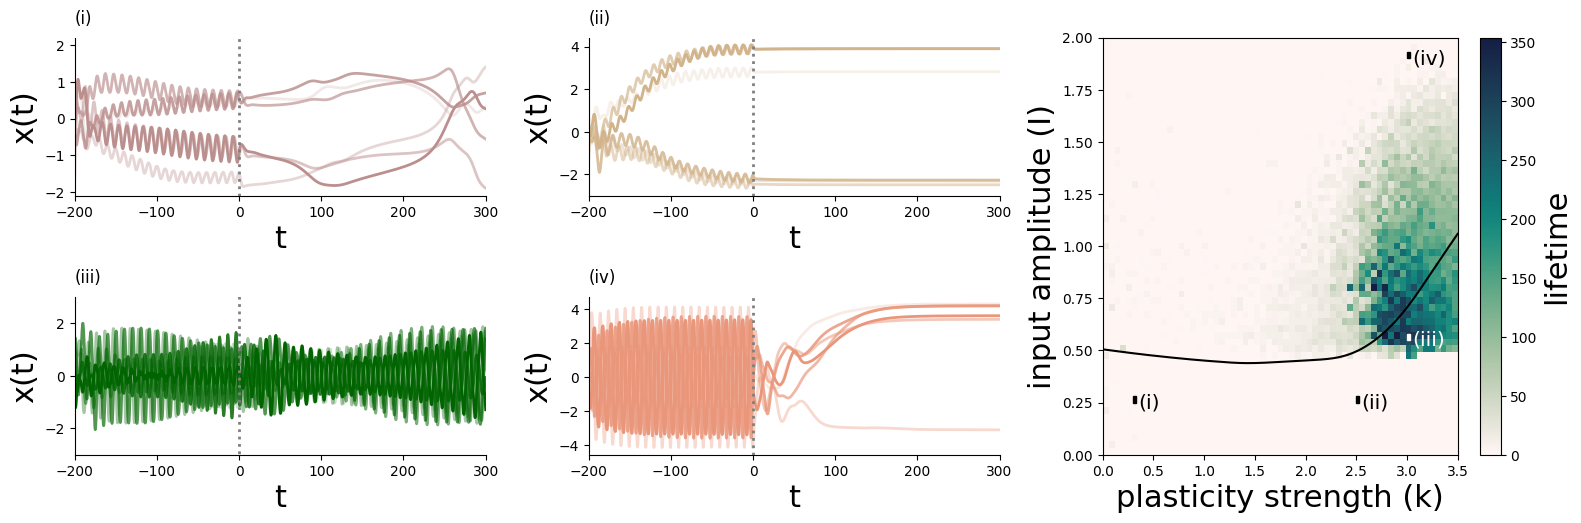

In [6]:
out = outdir + '/grid/example_sim.npy'
Xs = np.load(out, allow_pickle=True)
b=9#5#2#9 #5 #2
Xs = Xs[:, b]
# coordinates of the examples
ks = [0.3, 2.5, 3.0, 3.0]
Is = [0.25, 0.25, 0.55, 1.9] 
T = 700
N=500
halt_time = 2/7

w = 16
hw_r = 5/15 
fig, axs = plt.subplot_mosaic([['b', 'c', 'a'], ['d', 'e', 'a']], figsize=(w, w * hw_r ),
                             width_ratios=[1.25,1.25,1.35])

trace_ax = ['b', 'c', 'd', 'e']
colors = ['rosybrown', 'tan', 'darkgreen', 'darksalmon']
fn=22
nums = ['(i)', '(ii)', '(iii)', '(iv)']
for i, a in enumerate(trace_ax):  
    plot_fancy(Xs[i], axs[a], color=colors[i], fn=fn, T=T, halt_time=halt_time)
    axs[a].set_title(nums[i], loc='left', pad=10)

# phase diagram 


bisec_path = outdir + '/entrainment_bisection/T_5000_entrain_p_25_f_0.1_g_1.3_N_500_Nbatch_9'
grid_path = outdir + f'/grid/grid_N_500_Nb_50_dt_0.1_w_400_T_{T}_halt_0.29/summ_stats.csv'

coords = [[k, I] for k, I in zip(ks, Is)]


df = pd.read_csv(grid_path)

df['life'] = np.maximum(0, df.life - T*halt_time) 
df = df.groupby(['k','I']).median().reset_index()

mp = cmaps.tempo
tcol = 'black'
spline = True
vals=phase_diagram_heatmap(bisec_path, df, axs['a'], mp=mp, tcol=tcol, spline=spline)
label_diagram(coords, axs['a'], tcol=tcol) 
axs['d'].set_ylim([-3,3])
plt.tight_layout()
plt.show()
fig.savefig(figdir + '/heatmap_phase.png', dpi=300,
           bbox_inches='tight',transparent=True)